In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset from CSV file
df = pd.read_csv("df.csv")

# Drop the 'Unnamed: 0' index column if it exists to clean the dataframe
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Convert the 'CreatedOn' column to datetime objects for time-series analysis
# 'coerce' handles any parsing errors by setting them to NaT
df["CreatedOn"] = pd.to_datetime(df["CreatedOn"], errors="coerce")

C:\Users\sajal\AppData\Local\Temp\ipykernel_9344\3511325234.py:6: DtypeWarning: Columns (0: Unnamed: 11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("df.csv")


In [17]:
# Display basic information about the dataset
# Print the shape (rows, columns) of the dataframe
print("Shape:", df.shape)

# Print data types of each column
print("\nData types:\n", df.dtypes)

# Check for and count missing values in each column
print("\nMissing values:\n", df.isnull().sum())

# Display descriptive statistics (count, mean, std, min, max, etc.) for numeric columns
print("\nDescriptive statistics:\n", df.describe())

Shape: (461797, 11)

Data types:
 Dist Name                 str
Pest                      str
CreatedOn      datetime64[us]
pest_count              int64
Unnamed: 5            float64
Unnamed: 6            float64
Unnamed: 7            float64
Unnamed: 8            float64
Unnamed: 9            float64
Unnamed: 10           float64
Unnamed: 11               str
dtype: object

Missing values:
 Dist Name           0
Pest                0
CreatedOn           0
pest_count          0
Unnamed: 5     461797
Unnamed: 6     461797
Unnamed: 7     461797
Unnamed: 8     461797
Unnamed: 9     461797
Unnamed: 10    461797
Unnamed: 11    444759
dtype: int64

Descriptive statistics:
                         CreatedOn     pest_count  Unnamed: 5  Unnamed: 6  \
count                      461797  461797.000000         0.0         0.0   
mean   2015-06-22 18:58:52.029875       1.430185         NaN         NaN   
min           2013-01-01 00:00:00       1.000000         NaN         NaN   
25%           2014-

In [18]:
# Identify the time range of the data
# Print the earliest date in the dataset
print("Start date:", df["CreatedOn"].min())

# Print the latest date in the dataset
print("End date:", df["CreatedOn"].max())

Start date: 2013-01-01 00:00:00
End date: 2017-09-26 00:00:00


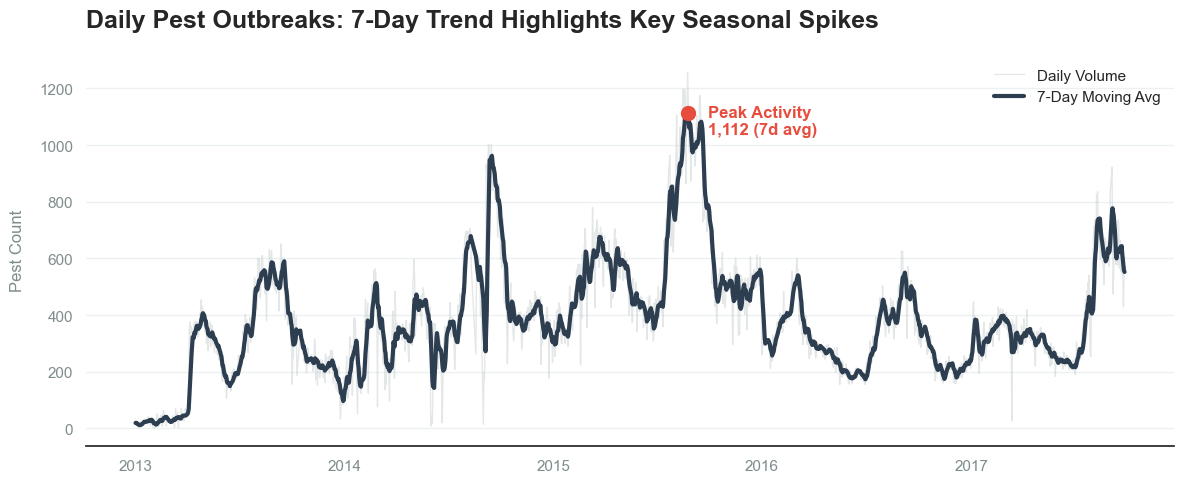

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ultra-minimal consulting theme
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

# Aggregate pest counts by day
daily_ts = df.groupby("CreatedOn")["pest_count"].sum()

# Calculate a 7-day rolling average to reduce visual noise (very common for daily data)
rolling_7d = daily_ts.rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Plot raw data as a faint background line
sns.lineplot(x=daily_ts.index, y=daily_ts.values, color="#bdc3c7", linewidth=1, alpha=0.4, ax=ax, label="Daily Volume")

# Plot smoothed trend line prominently
sns.lineplot(x=rolling_7d.index, y=rolling_7d.values, color="#2c3e50", linewidth=3, ax=ax, label="7-Day Moving Avg")

# Highlight Maximum Point on the trend
max_date, max_val = rolling_7d.idxmax(), rolling_7d.max()
ax.scatter([max_date], [max_val], color='#e74c3c', s=100, zorder=5)
ax.annotate(f"Peak Activity\n{max_val:,.0f} (7d avg)", xy=(max_date, max_val), 
            xytext=(15, -15), textcoords="offset points", 
            color="#e74c3c", fontweight="bold", fontsize=12)

# Minimalist titles and labels
plt.title("Daily Pest Outbreaks: 7-Day Trend Highlights Key Seasonal Spikes", fontsize=18, fontweight="bold", loc="left", pad=20)
plt.xlabel("") # Remove redundant "Date" label
plt.ylabel("Pest Count", fontsize=12, labelpad=10, color="#7f8c8d")
plt.xticks(fontsize=11, color="#7f8c8d")
plt.yticks(fontsize=11, color="#7f8c8d")

# Clean up legend and grid
ax.legend(frameon=False, loc="upper right", fontsize=11)
ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

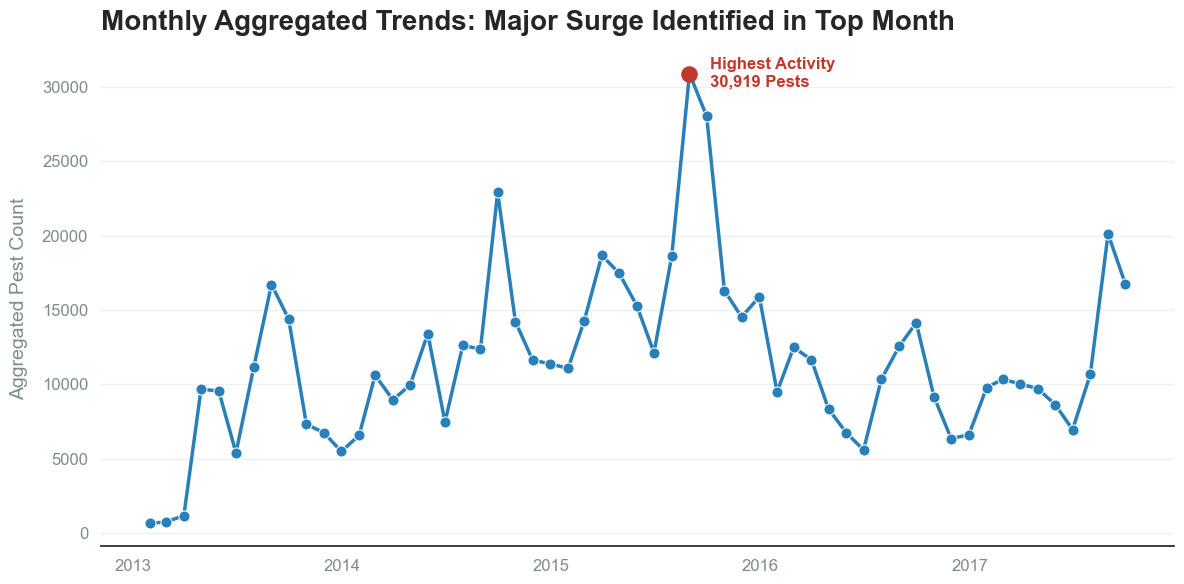

In [20]:
# Keep the modern theme consistent
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

# Resample the data to get monthly sums of pest counts ('ME' stands for Month End frequency)
monthly_ts = df.set_index("CreatedOn").resample("ME")["pest_count"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=monthly_ts.index, y=monthly_ts.values, marker="o", markersize=8, color="#2980b9", linewidth=2.5, ax=ax)

max_month, max_val = monthly_ts.idxmax(), monthly_ts.max()
ax.scatter([max_month], [max_val], color='#c0392b', s=120, zorder=5)
ax.annotate(f"Highest Activity\n{max_val:,.0f} Pests",
            xy=(max_month, max_val), xytext=(15, 0), textcoords="offset points", 
            color="#c0392b", fontweight="bold", fontsize=12, va="center")

plt.title("Monthly Aggregated Trends: Major Surge Identified in Top Month", fontsize=20, fontweight="bold", loc="left", pad=15)
plt.xlabel("") # Minimalist: month names imply the x-axis
plt.ylabel("Aggregated Pest Count", fontsize=14, labelpad=10, color="#7f8c8d")
plt.xticks(fontsize=12, rotation=0, color="#7f8c8d")
plt.yticks(fontsize=12, color="#7f8c8d")

ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

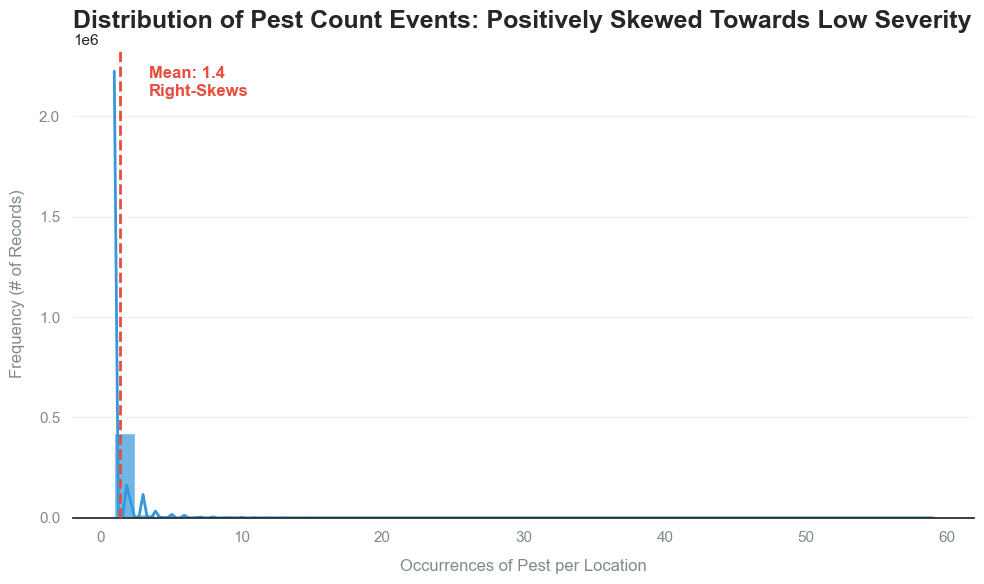

In [21]:
import numpy as np

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

fig, ax = plt.subplots(figsize=(10, 6))

hist_color = "#3498db"
kde_color = "#16a085"

sns.histplot(df["pest_count"], bins=40, kde=True, color=hist_color, edgecolor="white", alpha=0.7, ax=ax, line_kws={"color": kde_color, "lw": 2})

mean_val = df["pest_count"].mean()
ax.axvline(mean_val, color="#e74c3c", linestyle="dashed", linewidth=2, zorder=5)
ax.text(mean_val + 2, ax.get_ylim()[1]*0.9, f"Mean: {mean_val:.1f}\nRight-Skews", color="#e74c3c", fontweight="bold")

plt.title("Distribution of Pest Count Events: Positively Skewed Towards Low Severity", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.xlabel("Occurrences of Pest per Location", fontsize=12, labelpad=10, color="#7f8c8d")
plt.ylabel("Frequency (# of Records)", fontsize=12, labelpad=10, color="#7f8c8d")
plt.xticks(fontsize=11, color="#7f8c8d")
plt.yticks(fontsize=11, color="#7f8c8d")

ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

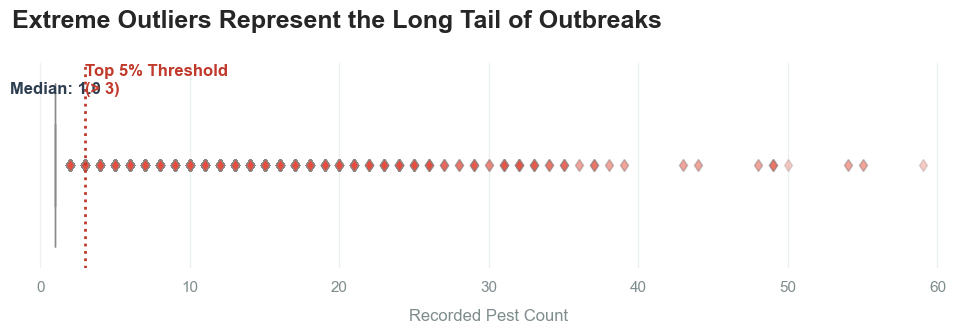

In [22]:
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False, "axes.spines.bottom": False})

fig, ax = plt.subplots(figsize=(10, 3.5))

sns.boxplot(x=df["pest_count"], color="#e0e6ed", flierprops={"marker": "d", "markerfacecolor": "#e74c3c", "markersize": 6, "alpha": 0.3}, ax=ax)

median_val = df["pest_count"].median()
perc95_val = df["pest_count"].quantile(0.95)

ax.text(median_val, ax.get_ylim()[1]+0.15, f"Median: {median_val}", color="#2c3e50", fontweight="bold", ha="center")
ax.axvline(perc95_val, color="#c0392b", linestyle=":", linewidth=2)

# Adjusted position higher up so the text doesn't fall off the plot bounds easily
ax.text(perc95_val, ax.get_ylim()[1]+0.15, f"Top 5% Threshold\n(> {perc95_val:.0f})", color="#c0392b", fontweight="bold")

plt.title("Extreme Outliers Represent the Long Tail of Outbreaks", fontsize=18, fontweight="bold", loc="left", pad=25)
plt.xlabel("Recorded Pest Count", fontsize=12, labelpad=10, color="#7f8c8d")
plt.yticks([])
plt.xticks(fontsize=11, color="#7f8c8d")

ax.grid(visible=True, axis="x", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="y")

plt.tight_layout()
plt.show()

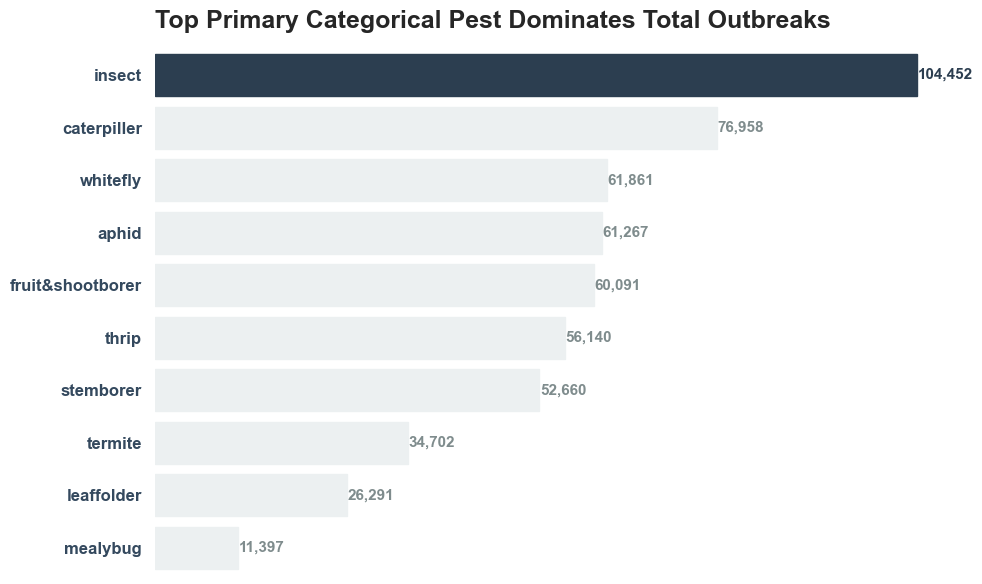

In [23]:
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.bottom": False, "axes.spines.left": False})

fig, ax = plt.subplots(figsize=(10, 6))

top_pests = df.groupby("Pest")["pest_count"].sum().sort_values(ascending=False).head(10)
bars = sns.barplot(x=top_pests.values, y=top_pests.index, order=top_pests.index, ax=ax, orient="h")

# Highlight #1 pest with distinct color
for i, bar in enumerate(bars.patches):
    if i == 0:
        bar.set_color("#2c3e50") # Deep bold blue/grey for top
    else:
        bar.set_color("#ecf0f1") # Muted grey for others

    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height() / 2, f"{int(width):,}", 
            va="center", ha="left", fontsize=11, fontweight="bold", color="#7f8c8d" if i > 0 else "#2c3e50")

plt.title("Top Primary Categorical Pest Dominates Total Outbreaks", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.xlabel("")
plt.ylabel("")
plt.yticks(fontsize=12, fontweight="bold", color="#34495e")
plt.xticks([])
ax.grid(visible=False)

plt.tight_layout()
plt.show()

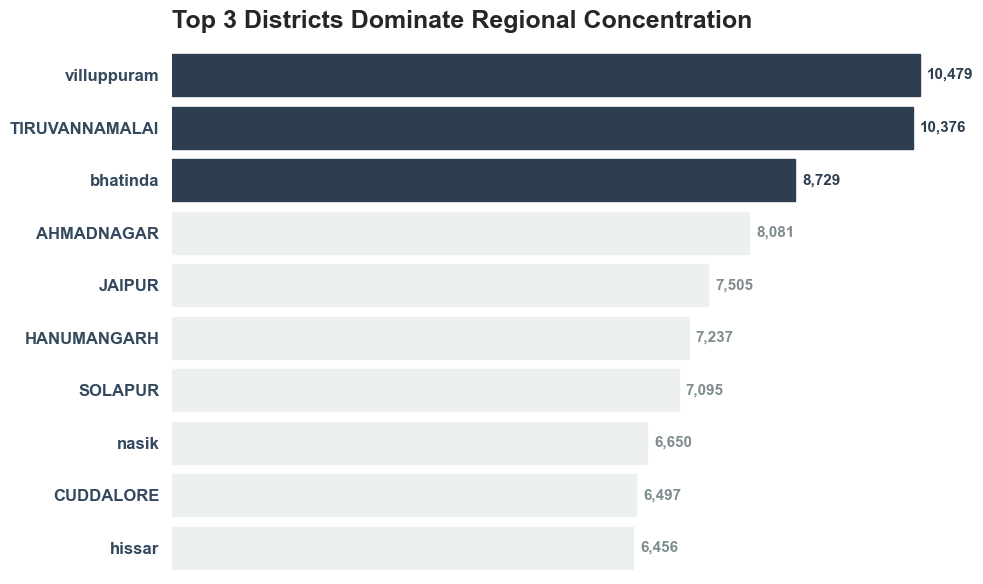

In [24]:
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.bottom": False, "axes.spines.left": False})

fig, ax = plt.subplots(figsize=(10, 6))

top_districts = df.groupby("Dist Name")["pest_count"].sum().sort_values(ascending=False).head(10)
bars = sns.barplot(x=top_districts.values, y=top_districts.index, order=top_districts.index, orient="h", ax=ax)

# Emphasize top 3
colors = ["#2c3e50"] * 3 + ["#ecf0f1"] * 7
for idx, bar in enumerate(bars.patches):
    bar.set_color(colors[idx])
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height() / 2, f"{int(width):,}", 
            va="center", ha="left", fontsize=11, fontweight="bold", color=colors[idx] if idx < 3 else "#7f8c8d")

plt.title("Top 3 Districts Dominate Regional Concentration", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.ylabel("")
plt.xlabel("")
plt.yticks(fontsize=12, fontweight="bold", color="#34495e")
plt.xticks([])
ax.grid(visible=False)

plt.tight_layout()
plt.show()

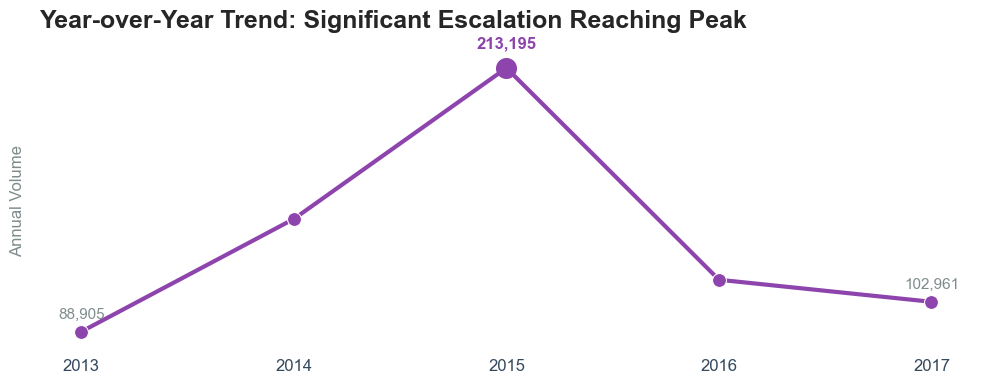

In [25]:
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False, "axes.spines.bottom": False})

df["Year"] = df["CreatedOn"].dt.year
yearly_ts = df.groupby("Year")["pest_count"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=yearly_ts.index, y=yearly_ts.values, marker='o', markersize=10, linewidth=3, color="#8e44ad", ax=ax)

for x, y in zip(yearly_ts.index, yearly_ts.values):
    # Only label min and max or first/last to be minimal
    if y == yearly_ts.max():
        ax.annotate(f"{y:,.0f}", xy=(x, y), xytext=(0, 15), textcoords="offset points", ha='center', fontweight='bold', fontsize=12, color="#8e44ad")
        ax.scatter([x], [y], color='#8e44ad', s=200, zorder=6)
    elif x == yearly_ts.index.min() or x == yearly_ts.index.max():
        ax.annotate(f"{y:,.0f}", xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', fontsize=11, color="#7f8c8d")

plt.title("Year-over-Year Trend: Significant Escalation Reaching Peak", fontsize=18, fontweight="bold", loc="left", pad=20)
plt.xlabel("") # obvious it's year
plt.ylabel("Annual Volume", fontsize=12, labelpad=10, color="#7f8c8d")
plt.xticks(yearly_ts.index, fontsize=12, color="#34495e")
plt.yticks([])

# Make grid visible on Y, but really subtle
ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

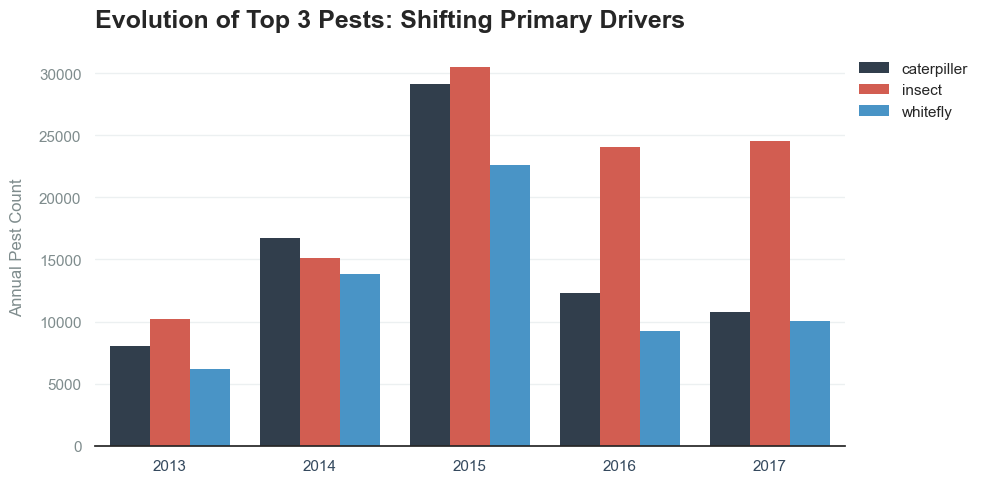

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload dataset to ensure clean state for this block
df = pd.read_csv("df.csv", low_memory=False)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df["CreatedOn"] = pd.to_datetime(df["CreatedOn"], errors="coerce")
df["Year"] = df["CreatedOn"].dt.year

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

# Limit to top 3 pests for ultimate clarity on slides
top_pests = df.groupby("Pest")["pest_count"].sum().sort_values(ascending=False).head(3).index

pest_yearly = df[df["Pest"].isin(top_pests)].groupby(["Year", "Pest"])["pest_count"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

# Use strong categorical colors commonly used by presentation decks
palette = ["#2c3e50", "#e74c3c", "#3498db"]

sns.barplot(data=pest_yearly, x="Year", y="pest_count", hue="Pest", 
            palette=palette, edgecolor="none", ax=ax)

plt.title("Evolution of Top 3 Pests: Shifting Primary Drivers", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.ylabel("Annual Pest Count", fontsize=12, labelpad=10, color="#7f8c8d")
plt.xlabel("") # Year implied
plt.xticks(fontsize=11, color="#34495e")
plt.yticks(fontsize=11, color="#7f8c8d")

plt.legend(title="", fontsize=11, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

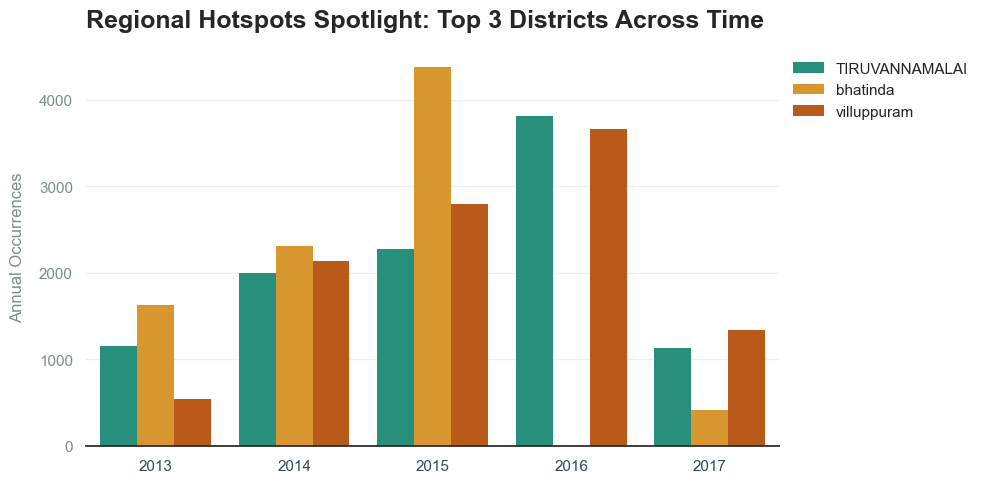

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify the top 3 districts for presentation clarity
top_districts = df.groupby("Dist Name")["pest_count"].sum().sort_values(ascending=False).head(3).index

# Aggregate data by Year and District for the top 3 districts
district_yearly = df[df["Dist Name"].isin(top_districts)].groupby(["Year", "Dist Name"])["pest_count"].sum().reset_index()

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})

fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#16a085", "#f39c12", "#d35400"]

sns.barplot(data=district_yearly, x="Year", y="pest_count", hue="Dist Name", 
            palette=palette, edgecolor="none", ax=ax)

plt.title("Regional Hotspots Spotlight: Top 3 Districts Across Time", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.ylabel("Annual Occurrences", fontsize=12, labelpad=10, color="#7f8c8d")
plt.xlabel("") # Implied by years

plt.legend(title="", fontsize=11, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.xticks(fontsize=11, color="#34495e")
plt.yticks(fontsize=11, color="#7f8c8d")

ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

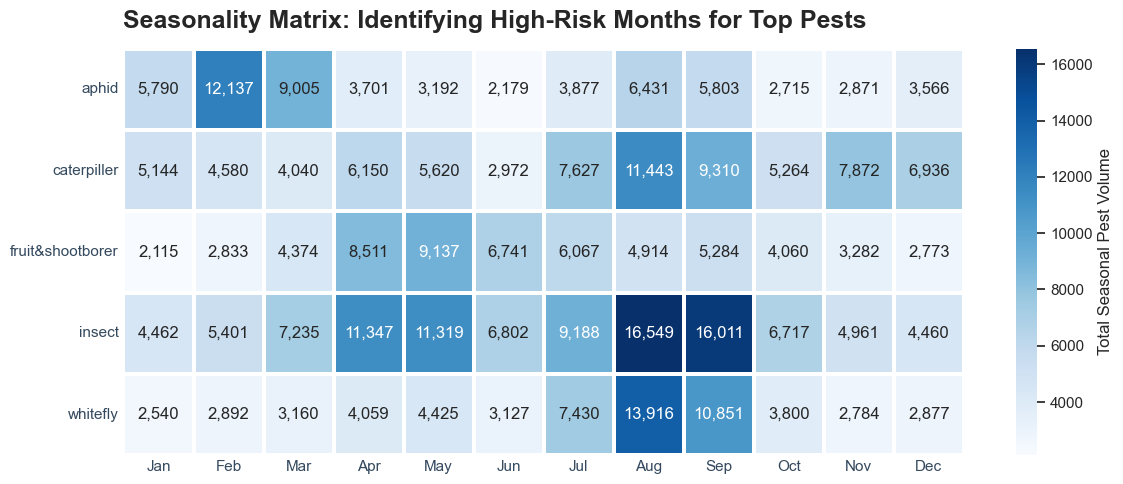

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload dataset 
df = pd.read_csv("df.csv", low_memory=False)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
df["CreatedOn"] = pd.to_datetime(df["CreatedOn"], errors="coerce")

sns.set_theme(style="white")

# Feature Engineering: Extract the month
df["Month"] = df["CreatedOn"].dt.month

# Filter to top 5 pests to keep the matrix clean
top_pests = df.groupby("Pest")["pest_count"].sum().sort_values(ascending=False).head(5).index
filtered_df = df[df["Pest"].isin(top_pests)].copy()

# Pivot the data: Pests vs Months
seasonality_df = filtered_df.pivot_table(
    index="Pest", 
    columns="Month", 
    values="pest_count", 
    aggfunc="sum"
).fillna(0)

# Reorder and map month indexes to actual text names
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# Ensure correct 1-12 order
ordered_months = sorted([m for m in seasonality_df.columns if pd.notnull(m)])
seasonality_df = seasonality_df[ordered_months]
seasonality_df.columns = [month_map.get(c, c) for c in seasonality_df.columns]

# Create the Heatmap Figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot heatmap using a high-contrast 'Blues' colormap
sns.heatmap(seasonality_df, cmap="Blues", annot=True, fmt=",.0f", linewidths=1.5, 
            cbar_kws={'label': 'Total Seasonal Pest Volume'}, ax=ax)

# Clean up styling 
plt.title("Seasonality Matrix: Identifying High-Risk Months for Top Pests", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.xlabel("") # Months implied
plt.ylabel("") # Pest implied

# Adjust labels
plt.xticks(fontsize=11, color="#34495e", rotation=0)
plt.yticks(fontsize=11, color="#34495e", rotation=0)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

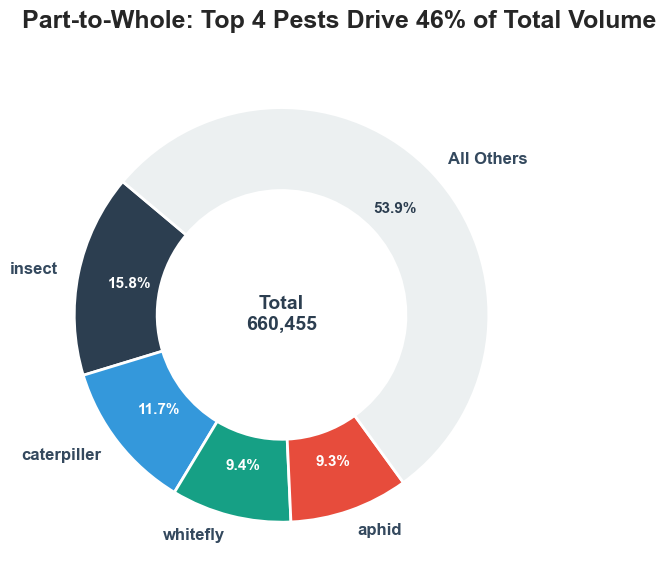

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload dataset 
df = pd.read_csv("df.csv", low_memory=False)

# Part-to-Whole Relationship: Donut Chart 
# (Highly effective for consulting slides to show concentration/dominance)

# Calculate part-to-whole for pests
pest_totals = df.groupby('Pest')['pest_count'].sum().sort_values(ascending=False)

# Group into "Top 4" and "All Others" to prevent clutter
top_4 = pest_totals.head(4)
others = pd.Series({'All Others': pest_totals.iloc[4:].sum()})
donut_data = pd.concat([top_4, others])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2c3e50", "#3498db", "#16a085", "#e74c3c", "#ecf0f1"]

wedges, texts, autotexts = ax.pie(
    donut_data, 
    labels=donut_data.index, 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors, 
    pctdistance=0.75, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

# Text styling for a premium look
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
    text.set_color('#34495e')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    # Make the "All Others" text dark so it's readable on the light grey background
    if autotext.get_text() == f"{donut_data['All Others']/donut_data.sum()*100:.1f}%":
        autotext.set_color('#2c3e50')
    else:
        autotext.set_color('white')

# Adding a central label
center_circle = plt.Circle((0,0), 0.55, fc='white')
fig.gca().add_artist(center_circle)
plt.text(0, 0, f"Total\n{donut_data.sum():,.0f}", ha='center', va='center', fontsize=14, fontweight='bold', color='#2c3e50')

# Insightful Title
top_n_pct = (top_4.sum() / donut_data.sum()) * 100
plt.title(f"Part-to-Whole: Top 4 Pests Drive {top_n_pct:.0f}% of Total Volume", fontsize=18, fontweight="bold", loc="left", pad=20)

plt.tight_layout()
plt.show()

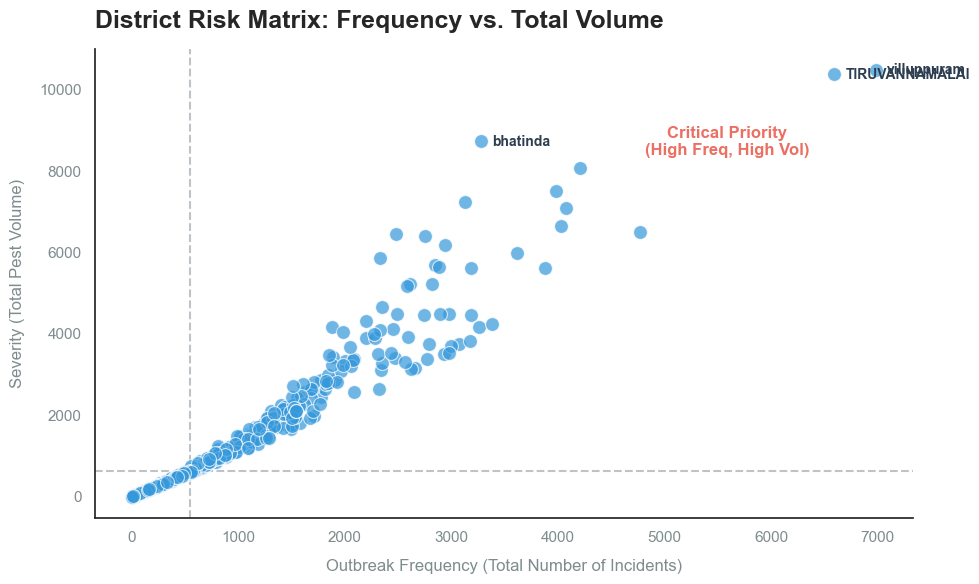

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload dataset 
df = pd.read_csv("df.csv", low_memory=False)

# -------------------------------------------------------------
# Chart 1: The "Consulting Matrix" (Quadrant Scatter Plot)
# Use When: Analyzing the relationship between two variables 
# to categorize entities into strategic quadrants
# -------------------------------------------------------------

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})

# Calculate Frequency (count of records) and Severity (sum of pest_count) per District
district_stats = df.groupby("Dist Name").agg(
    Frequency=("pest_count", "count"),
    Total_Volume=("pest_count", "sum")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the scatter
sns.scatterplot(data=district_stats, x="Frequency", y="Total_Volume", 
                color="#3498db", s=100, alpha=0.7, edgecolor="white", ax=ax)

# Draw Median lines to create 4 Strategic Quadrants
x_med = district_stats["Frequency"].median()
y_med = district_stats["Total_Volume"].median()
ax.axvline(x_med, color="#bdc3c7", linestyle="--", linewidth=1.5, zorder=0)
ax.axhline(y_med, color="#bdc3c7", linestyle="--", linewidth=1.5, zorder=0)

# Annotate the extreme outliers (Top 3 by Volume) for context
top_districts = district_stats.nlargest(3, "Total_Volume")
for _, row in top_districts.iterrows():
    ax.annotate(row["Dist Name"], (row["Frequency"], row["Total_Volume"]), 
                xytext=(8, -3), textcoords='offset points', fontweight="bold", color="#2c3e50", fontsize=10)

# Label the High-Risk Quadrant
ax.text(district_stats["Frequency"].max() * 0.8, district_stats["Total_Volume"].max() * 0.8, 
        "Critical Priority\n(High Freq, High Vol)", color="#e74c3c", fontweight="bold", alpha=0.8, fontsize=12, ha="center")

# Styling
plt.title("District Risk Matrix: Frequency vs. Total Volume", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.xlabel("Outbreak Frequency (Total Number of Incidents)", fontsize=12, labelpad=10, color="#7f8c8d")
plt.ylabel("Severity (Total Pest Volume)", fontsize=12, labelpad=10, color="#7f8c8d")

plt.xticks(fontsize=11, color="#7f8c8d")
plt.yticks(fontsize=11, color="#7f8c8d")

plt.tight_layout()
plt.show()

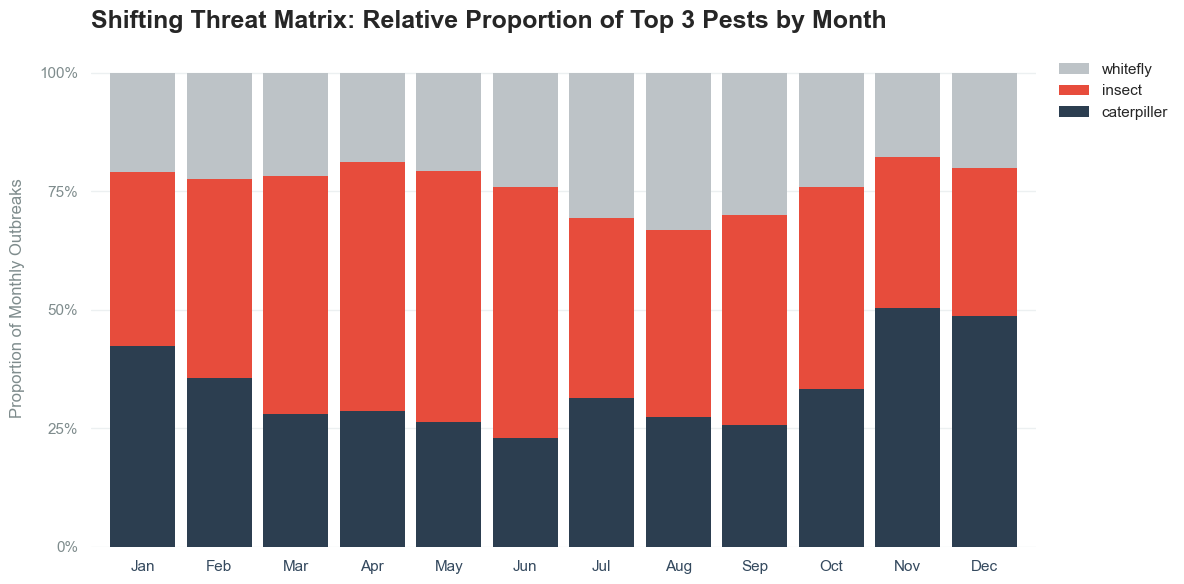

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload dataset 
df = pd.read_csv("df.csv", low_memory=False)

# -------------------------------------------------------------
# Chart 2: 100% Stacked Bar Chart 
# Use When: Showing "Part-to-Whole Relationship" over Time 
# Understanding changing compositions visually
# -------------------------------------------------------------

df["CreatedOn"] = pd.to_datetime(df["CreatedOn"], errors="coerce")
df["Month"] = df["CreatedOn"].dt.month

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False, "axes.spines.bottom": False})

# Limit to Top 3 Pests to avoid clutter
top_3_pests = df.groupby("Pest")["pest_count"].sum().nlargest(3).index

# Prepare composition dataframe
comp_df = df[df["Pest"].isin(top_3_pests)].copy()
cross_tab = pd.crosstab(comp_df["Month"], comp_df["Pest"], values=comp_df["pest_count"], aggfunc="sum").fillna(0)

# Normalize to 100%
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# Month labels mapping
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
cross_tab_pct = cross_tab_pct.rename(index=month_map)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2c3e50", "#e74c3c", "#bdc3c7"] # Strong consulting palette: Main, Alert, Neutral
cross_tab_pct.plot(kind="bar", stacked=True, color=colors, width=0.85, ax=ax, edgecolor="white", linewidth=0)

# Style text & Layout
plt.title("Shifting Threat Matrix: Relative Proportion of Top 3 Pests by Month", fontsize=18, fontweight="bold", loc="left", pad=15)
plt.xlabel("") # Implied by months
plt.ylabel("Proportion of Monthly Outbreaks", fontsize=12, labelpad=10, color="#7f8c8d")

plt.xticks(rotation=0, fontsize=11, color="#34495e")
plt.yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], fontsize=11, color="#7f8c8d")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="", bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=11)

ax.grid(visible=True, axis="y", color="#ecf0f1", linestyle="-", linewidth=1)
ax.grid(visible=False, axis="x")

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import plotly.express as px

# -------------------------------------------------------------
# Chart 3: Geographical Heatmap (Density Map)
# Use When: Geographical analysis to plot data across countries/states/districts
# -------------------------------------------------------------

# Using merged_output.csv which already contains the latitude and longitude
try:
    merged_geo = pd.read_csv("merged_output.csv", low_memory=False)
    
    # Aggregate pest_count by district, latitude, and longitude
    geo_df = merged_geo.groupby(["district", "latitude", "longitude"], as_index=False)["pest_count"].sum()

    # Use the non-deprecated density map function
    fig = px.density_map(
        geo_df,
        lat="latitude",
        lon="longitude",
        z="pest_count",
        radius=30,  # controls spread of heat
        center=dict(lat=geo_df["latitude"].mean(), lon=geo_df["longitude"].mean()),
        zoom=5,
        map_style="carto-positron",  # clean light mode map
        color_continuous_scale="YlOrRd",  # yellow -> red heat
        hover_name="district"
    )
    
    fig.update_layout(
        title=dict(
            text="<b>Geographical Outbreak Concentration</b><br><sup>High-Risk Heating identifies strict localized zones.</sup>",
            x=0.02,
            y=0.95,
            font=dict(size=18, color="#2c3e50")
        ),
        margin=dict(l=0, r=0, t=60, b=0),
        coloraxis_colorbar=dict(title="Volume")
    )
    
    fig.show()
except Exception as e:
    print(f"Error generating map: {str(e)}")

In [5]:
import pandas as pd
import plotly.express as px

# ================== LOAD DATA ==================
df = pd.read_csv("merged_output.csv")
print(df.columns)

# ================== AUTO-DETECT COLUMNS ==================
cols = [c.lower() for c in df.columns]

lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
lon_col = next((c for c in df.columns if "lon" in c.lower() or "lng" in c.lower()), None)

# ================== CASE 1: LAT/LON AVAILABLE ==================
if lat_col and lon_col:
    df_clean = df.dropna(subset=[lat_col, lon_col]).copy()
    df_clean.rename(columns={lat_col: "lat", lon_col: "lon"}, inplace=True)

# ================== CASE 2: USE DISTRICT/STATE ==================
else:
    # Basic India city/state mapping (expand if needed)
    location_map = {
        "delhi": (28.6, 77.2), "mumbai": (19.0, 72.8), "chennai": (13.0, 80.2),
        "kolkata": (22.5, 88.3), "lucknow": (26.8, 80.9), "kanpur": (26.4, 80.3),
        "hyderabad": (17.4, 78.5), "bangalore": (12.97, 77.59), "bengaluru": (12.97, 77.59),
        "pune": (18.5, 73.8), "ahmedabad": (23.0, 72.5), "jaipur": (26.9, 75.8),
        "bhopal": (23.25, 77.41), "patna": (25.6, 85.1), "ranchi": (23.34, 85.31)
    }

    # Find possible location column
    loc_col = next((c for c in df.columns if any(k in c.lower() for k in ["district", "city", "state"])), None)

    if loc_col is None:
        raise ValueError("No location column found (lat/lon or district/state required)")

    df["lat"] = df[loc_col].astype(str).str.lower().map(lambda x: location_map.get(x, (None, None))[0])
    df["lon"] = df[loc_col].astype(str).str.lower().map(lambda x: location_map.get(x, (None, None))[1])

    df_clean = df.dropna(subset=["lat", "lon"]).copy()

# ================== CREATE DENSITY ==================
df_grouped = df_clean.groupby(["lat", "lon"]).size().reset_index(name="count")

# ================== PLOT ==================
fig = px.density_mapbox(
    df_grouped,
    lat="lat",
    lon="lon",
    z="count",
    radius=30,
    center=dict(lat=22, lon=78),
    zoom=4.5,
    mapbox_style="carto-positron",
    color_continuous_scale="YlOrRd"
)

fig.update_traces(opacity=0.85)

fig.update_layout(
    title="Geographical Hotspots",
    title_x=0.5,
    title_font_size=20,
    font=dict(family="Arial"),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

Index(['district', 'Pest', 'CreatedOn', 'pest_count', 'latitude', 'longitude'], dtype='str')


C:\Users\sajal\AppData\Local\Temp\ipykernel_9344\2382091681.py:45: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(


In [6]:
import pandas as pd
import plotly.express as px

# ================== LOAD DATA ==================
df = pd.read_csv("merged_output.csv")

# ================== CLEAN DATA ==================
df_clean = df.dropna(subset=["latitude", "longitude", "pest_count"]).copy()

# Optional: aggregate for better density (VERY IMPORTANT for good heatmap)
df_grouped = df_clean.groupby(["latitude", "longitude"], as_index=False)["pest_count"].sum()

# ================== INDIA BOUNDING BOX FILTER ==================
# This removes outside regions and keeps only India
df_grouped = df_grouped[
    (df_grouped["latitude"] >= 6) & (df_grouped["latitude"] <= 37) &
    (df_grouped["longitude"] >= 68) & (df_grouped["longitude"] <= 97)
]

# ================== PLOT ==================
fig = px.density_mapbox(
    df_grouped,
    lat="latitude",
    lon="longitude",
    z="pest_count",
    radius=35,  # increase for smoother spread
    center=dict(lat=22, lon=79),  # center of India
    zoom=5.2,  # tighter zoom → focuses on India only
    mapbox_style="carto-positron",
    color_continuous_scale="YlOrRd"
)

# ================== STYLE ==================
fig.update_traces(opacity=0.9)

fig.update_layout(
    title="Geographical Hotspots",
    title_x=0.5,
    title_font_size=22,
    font=dict(family="Arial"),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Count")
)

fig.show()

C:\Users\sajal\AppData\Local\Temp\ipykernel_9344\1862688731.py:21: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(


In [7]:
import pandas as pd
import plotly.express as px

# ================== LOAD DATA ==================
df = pd.read_csv("merged_output.csv")

# ================== CLEAN DATA ==================
df_clean = df.dropna(subset=["latitude", "longitude", "pest_count"]).copy()

# Optional: aggregate for better density (VERY IMPORTANT for good heatmap)
df_grouped = df_clean.groupby(["latitude", "longitude"], as_index=False)["pest_count"].sum()

# ================== INDIA BOUNDING BOX FILTER ==================
# This removes outside regions and keeps only India
df_grouped = df_grouped[
    (df_grouped["latitude"] >= 6) & (df_grouped["latitude"] <= 37) &
    (df_grouped["longitude"] >= 68) & (df_grouped["longitude"] <= 97)
]

# ================== PLOT ==================
fig = px.density_mapbox(
    df_grouped,
    lat="latitude",
    lon="longitude",
    z="pest_count",
    radius=35,  # increase for smoother spread
    center=dict(lat=22, lon=79),  # center of India
    zoom=5.2,  # tighter zoom → focuses on India only
    mapbox_style="carto-positron",
    color_continuous_scale="YlOrRd"
)

# ================== STYLE ==================
fig.update_traces(opacity=0.9)

fig.update_layout(
    title="Geographical Hotspots",
    title_x=0.5,
    title_font_size=22,
    font=dict(family="Arial"),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Count")
)

fig.show()

C:\Users\sajal\AppData\Local\Temp\ipykernel_9344\1862688731.py:21: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(
